<a href="https://colab.research.google.com/github/ssykes-eth/ETH_273-0003-00L/blob/weekend_2/UNet%20Exercise/visual_unet_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U-Net Exercise: Segmenting Rectangles from Circles

In this exercise, you will learn how to use and to improve a U-Net for image segmentation. You will receive 10 images and teach the computer to differentiate rectangles from circles. The final output should only show the rectangles.


## Imports

In [12]:
#@title <Imports> {display-mode: "form"}
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

!wget https://raw.githubusercontent.com/eth-bmai-fs26/coding-exercises/week2/UNet%20Exercise%20Solution/shapes_data.py
from shapes_data import print_training_data_set, ShapesDataset, IMAGE_SIZE, generate_sample, display_results

torch.manual_seed(0)
np.random.seed(0)

--2026-03-07 08:20:57--  https://raw.githubusercontent.com/eth-bmai-fs26/coding-exercises/week2/UNet%20Exercise%20Solution/shapes_data.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1966 (1.9K) [text/plain]
Saving to: ‘shapes_data.py.1’

shapes_data.py.1    100%[===================>]   1.92K  --.-KB/s    in 0s      

2026-03-07 08:20:57 (39.5 MB/s) - ‘shapes_data.py.1’ saved [1966/1966]



## Training Data Set

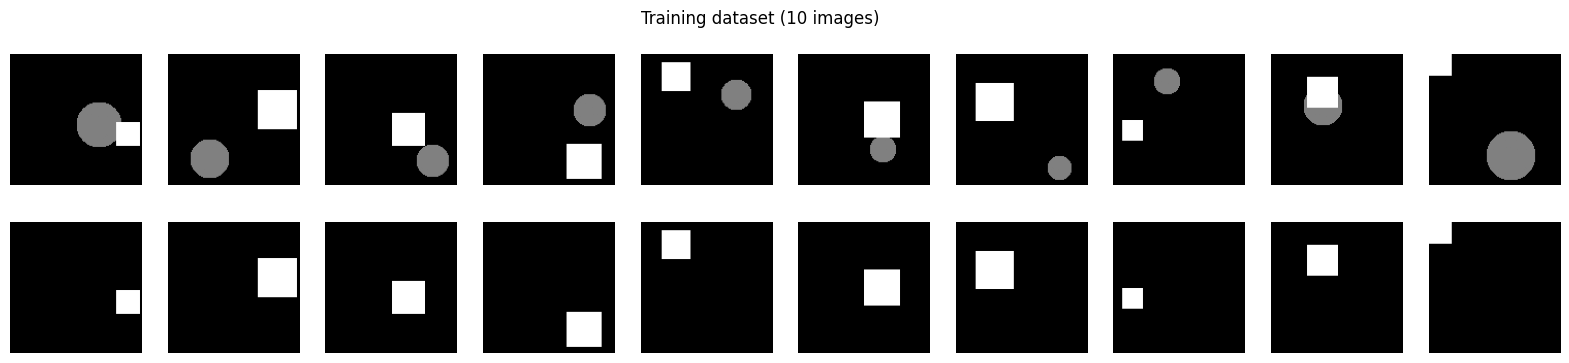

In [13]:
train_dataset = ShapesDataset(10)
test_dataset = ShapesDataset(10)
print_training_data_set(train_dataset)

## U-Net architecture

A **U-Net** is a neural network for **image segmentation**: it takes an image and predicts which pixels belong to which class.  

- **Channels**: are like layers showing different features. Grayscale images have 1 channel; color images have 3. The network creates more channels to detect edges, textures, and shapes.  
- **Encoder**: extracts features and reduces image size, like zooming out while remembering important details.  
- **Bottleneck**: the most compressed representation, containing abstract features.  
- **Decoder**: enlarges the image again and merges features from the encoder to recover spatial details.  
- **Output**: a new image/mask highlighting important parts.  

**In short:** U-Net looks at an image, learns patterns, and produces a mask while keeping the original details.


In [14]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder path
        self.enc1 = DoubleConv(1, 8)   # First double conv: input 1 channel → 8 channels
        self.enc2 = DoubleConv(8, 16)  # Second double conv: 8 → 16 channels

        self.pool = nn.MaxPool2d(2)    # Max pooling with 2x2 window, reduces spatial dimensions by half

        # Bottleneck
        self.bottleneck = DoubleConv(16, 32)  # Bottom of the U, feature expansion: 32 → 64 channels

        # Decoder path
        self.up2 = nn.ConvTranspose2d(32, 16, 2, 2)     # Upsample from 32 → 16 channels, doubles spatial dimensions
        self.dec2 = DoubleConv(32, 16)                  # After concatenation with skip connection: 16+16=32 → 16

        self.up1 = nn.ConvTranspose2d(16, 8, 2, 2)      # Upsample from 16 → 8 channels
        self.dec1 = DoubleConv(16, 8)                   # After concatenation with skip connection: 8+8=16 → 8

        # Final output layer
        self.out = nn.Conv2d(8, 1, 1)   # 1x1 convolution to reduce to desired output channels (e.g., segmentation mask)


    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)                   # Apply first double conv
        e2 = self.enc2(self.pool(e1))       # Pool e1 to reduce size, then apply second double conv#

        # Bottleneck
        b = self.bottleneck(self.pool(e2))  # Pool again, then double conv at the bottom of the U

        # Decoder
        d2 = self.up2(b)                    # Upsample bottleneck features
        d2 = torch.cat([d2, e2], dim=1)     # Concatenate skip connection from encoder (same spatial size)
        d2 = self.dec2(d2)                  # Process concatenated features with double conv

        d1 = self.up1(d2)                   # Upsample
        d1 = torch.cat([d1, e1], dim=1)     # Concatenate skip connection from first encoder
        d1 = self.dec1(d1)                  # Process with double conv

        # Output
        return self.out(d1)                 # Final 1x1 convolution to produce output

## Training

# U-Net Training Explained

**Inputs:**  
- The network receives an **image**.  

**Ground truth mask:**  
- For training, each image has a **mask** showing the correct labeling of pixels (e.g., 1 for rectangle, 0 for background).  

**Prediction:**  
- The U-Net outputs a **predicted mask** of the same size as the input.  

**Loss calculation:**  
- Compare the predicted mask with the ground truth mask using a **loss function** (e.g., Binary Cross-Entropy or Dice Loss).  
- The loss measures how close the prediction is to the truth.  

**Backpropagation:**  
- The network updates its weights to **minimize the loss**, improving mask predictions over time.  


Epoch 01 | Loss: 0.5352
Epoch 02 | Loss: 0.5238
Epoch 03 | Loss: 0.4956
Epoch 04 | Loss: 0.4142
Epoch 05 | Loss: 0.2511
Epoch 06 | Loss: 0.2195
Epoch 07 | Loss: 0.1674
Epoch 08 | Loss: 0.1628
Epoch 09 | Loss: 0.1536
Epoch 10 | Loss: 0.1281
Epoch 11 | Loss: 0.1435
Epoch 12 | Loss: 0.1188
Epoch 13 | Loss: 0.1024
Epoch 14 | Loss: 0.1030
Epoch 15 | Loss: 0.1018
Epoch 16 | Loss: 0.0872
Epoch 17 | Loss: 0.0780
Epoch 18 | Loss: 0.0703
Epoch 19 | Loss: 0.0838
Epoch 20 | Loss: 0.0869
Epoch 21 | Loss: 0.0713
Epoch 22 | Loss: 0.0683
Epoch 23 | Loss: 0.0604
Epoch 24 | Loss: 0.0669
Epoch 25 | Loss: 0.0548
Epoch 26 | Loss: 0.0509
Epoch 27 | Loss: 0.0398
Epoch 28 | Loss: 0.0198
Epoch 29 | Loss: 0.0092
Epoch 30 | Loss: 0.0086


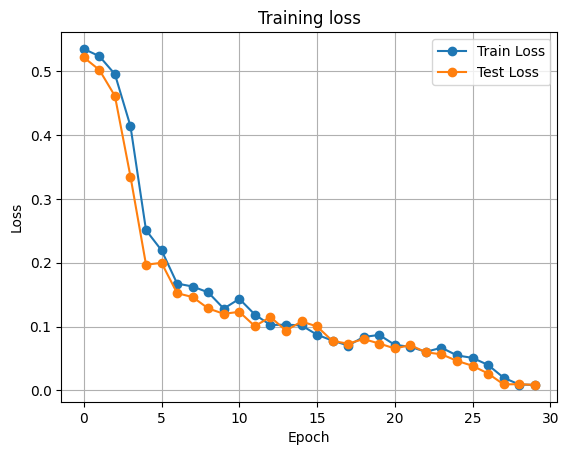

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

train_losses = []
test_losses = []

for epoch in range(30):
    # ---- Training phase ----
    train_epoch_loss = 0
    model.train()

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

        train_epoch_loss += loss.item()

    train_epoch_loss /= len(train_loader)
    train_losses.append(train_epoch_loss)
    print(f"Epoch {epoch+1:02d} | Loss: {train_epoch_loss:.4f}")

    # ---- Testing phase ----
    test_epoch_loss = 0
    model.eval()

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            loss = criterion(model(x), y)
            test_epoch_loss += loss.item()

    test_epoch_loss /= len(test_loader)
    test_losses.append(test_epoch_loss)

plt.plot(train_losses, marker="o", label="Train Loss")
plt.plot(test_losses, marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.legend()
plt.grid(True)
plt.show()

## Prediction on a new image

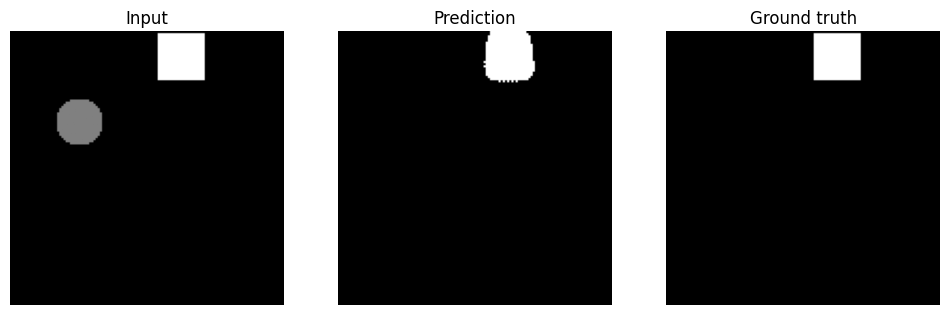

In [16]:
model.eval()
test_img, test_mask = generate_sample()

x = torch.tensor(test_img).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    pred = torch.sigmoid(model(x))[0, 0].cpu()

display_results(test_img, pred, test_mask)


# 🎯 Your Task

Follow the steps to add a third encoder layer and make our U-Net even more accurate. Try the code as is beforehand!

## Train the three layer U-Net (do not change this code)

Epoch 01 | Loss: 0.8053
Epoch 02 | Loss: 0.7901
Epoch 03 | Loss: 0.7735
Epoch 04 | Loss: 0.7414
Epoch 05 | Loss: 0.6624
Epoch 06 | Loss: 0.4300
Epoch 07 | Loss: 0.2861
Epoch 08 | Loss: 0.1927
Epoch 09 | Loss: 0.1199
Epoch 10 | Loss: 0.0942
Epoch 11 | Loss: 0.0765
Epoch 12 | Loss: 0.0818
Epoch 13 | Loss: 0.0616
Epoch 14 | Loss: 0.0673
Epoch 15 | Loss: 0.0482
Epoch 16 | Loss: 0.0561
Epoch 17 | Loss: 0.0475
Epoch 18 | Loss: 0.0404
Epoch 19 | Loss: 0.0289
Epoch 20 | Loss: 0.0195
Epoch 21 | Loss: 0.0120
Epoch 22 | Loss: 0.0112
Epoch 23 | Loss: 0.0087
Epoch 24 | Loss: 0.0063
Epoch 25 | Loss: 0.0067
Epoch 26 | Loss: 0.0065
Epoch 27 | Loss: 0.0054
Epoch 28 | Loss: 0.0045
Epoch 29 | Loss: 0.0047
Epoch 30 | Loss: 0.0036


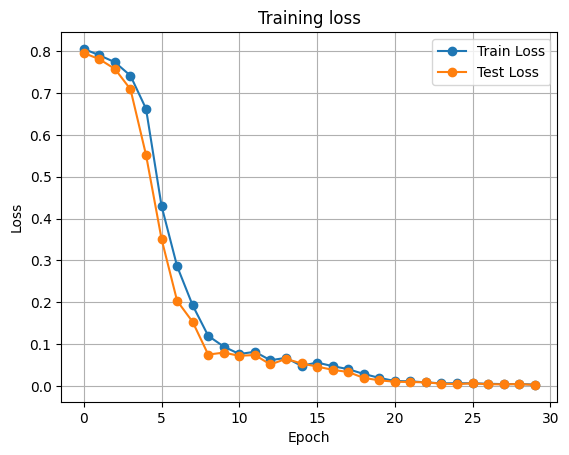

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

train_losses = []
test_losses = []

for epoch in range(30):
    # ---- Training phase ----
    train_epoch_loss = 0
    model.train()

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

        train_epoch_loss += loss.item()

    train_epoch_loss /= len(train_loader)
    train_losses.append(train_epoch_loss)
    print(f"Epoch {epoch+1:02d} | Loss: {train_epoch_loss:.4f}")

    # ---- Testing phase ----
    test_epoch_loss = 0
    model.eval()

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            loss = criterion(model(x), y)
            test_epoch_loss += loss.item()

    test_epoch_loss /= len(test_loader)
    test_losses.append(test_epoch_loss)

plt.plot(train_losses, marker="o", label="Train Loss")
plt.plot(test_losses, marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.legend()
plt.grid(True)
plt.show()

## Prediction on a new image with the optimised U-Net

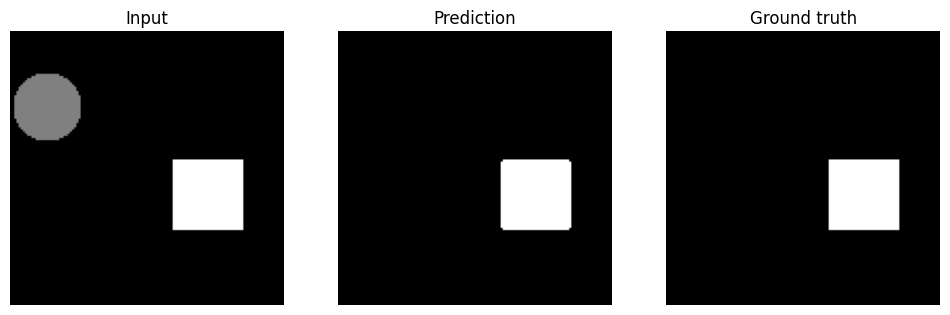

In [18]:
model.eval()
test_img, test_mask = generate_sample()

x = torch.tensor(test_img).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    pred = torch.sigmoid(model(x))[0, 0].cpu()

display_results(test_img, pred, test_mask)


## Final Words

Congratulations, you should now be able to work with basic U-Nets. 🥳

Final questions for you:
- Did the prediction improve when adding a new layer?
- What would you change next?